In [114]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import itertools
import scipy.stats as stats
import numpy as np
from statsmodels.stats.anova import AnovaRM
from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests
df = pd.read_csv("resultat_dummy_6000.csv")
df.columns = df.columns.str.strip()
df["absolute_error"] = abs(
    df["AI vurderet rigtig"]
    - df["faktuelt rigtige"]
)
df["signed_error"] = (df["AI vurderet rigtig"]-df["faktuelt rigtige"])
Fakta_rigtig=df["faktuelt rigtige"]
prompt_names = {
    0: "Highly unceratain",
    1: "negative",
    2: "Neutral",
    3: "Positive",
    4: "Highly confident"
}
df["prompt_navn"] = df["prompt"].map(prompt_names)

In [ ]:
#Signed og absolut error pr prompt-type
gennemsnit_fejl = (df.groupby("prompt")[["signed_error", "absolute_error"]].mean().reset_index())
gennemsnit_fejl["prompt_navn"] = (gennemsnit_fejl["prompt"].map(prompt_names))
gennemsnit_fejl_tabel = gennemsnit_fejl[
[
        "prompt",
        "prompt_navn",
        "signed_error",
        "absolute_error"
    ]
]

print(gennemsnit_fejl_tabel.to_string(index=False))

 prompt       prompt_navn  signed_error  absolute_error
      0 Highly unceratain     -1.345833        2.179167
      1          negative     -0.815833        1.627500
      2           Neutral     -0.018333        0.873333
      3          Positive      1.119167        1.734167
      4  Highly confident      0.535000        0.936667


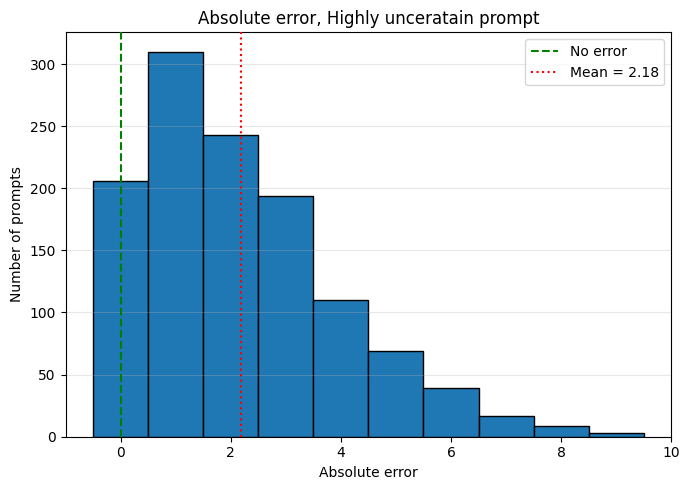

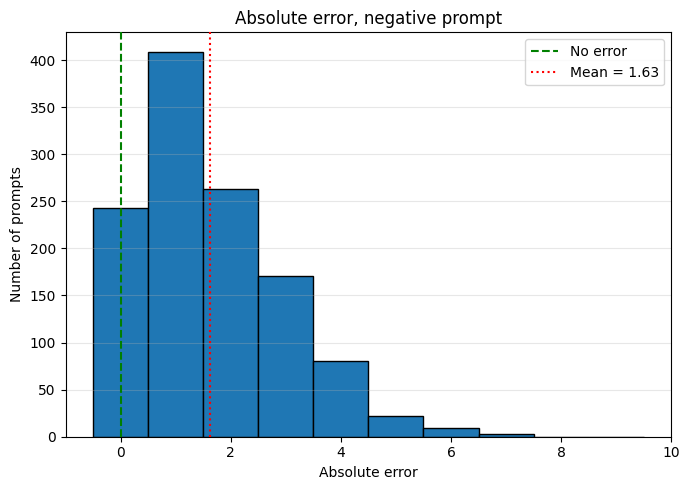

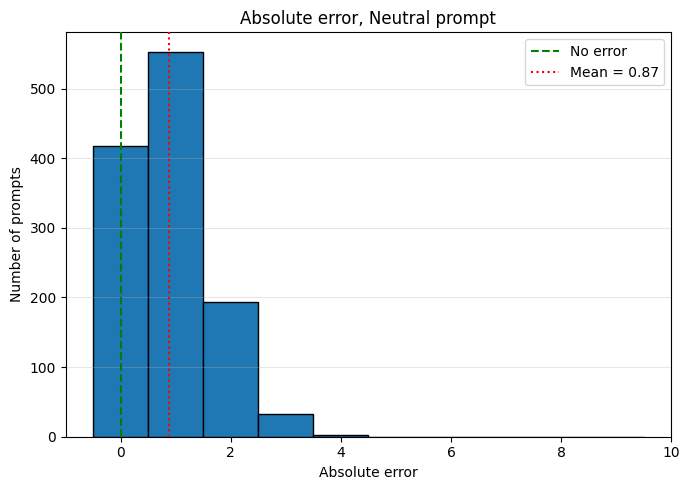

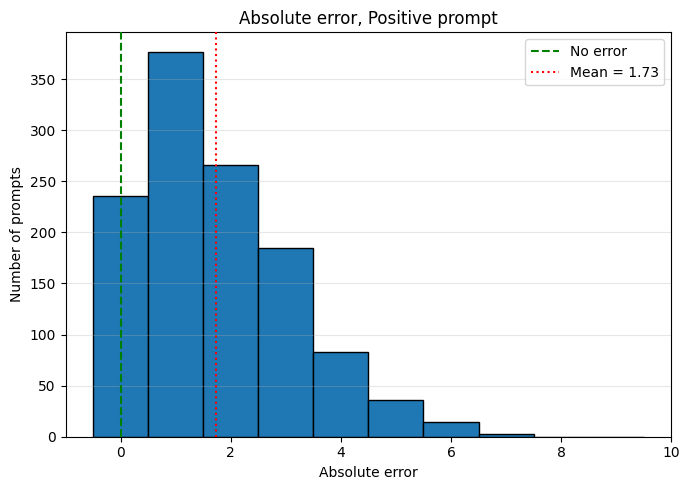

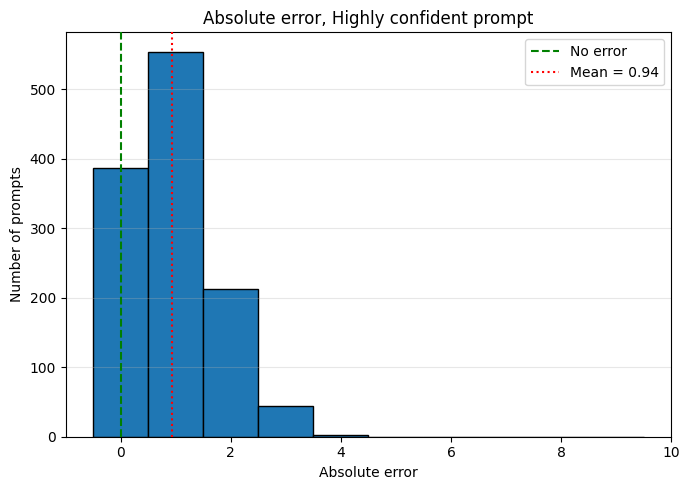

In [ ]:
#histogram over absolut error
absolute_min = int(df["absolute_error"].min())
absolute_max = int(df["absolute_error"].max())

absolute_hist = np.arange(
    absolute_min - 0.5,
    absolute_max + 1.5,
    1
)

for prompt, group in df.groupby("prompt"):

    plt.figure(figsize=(7, 5))

    plt.hist(
        group["absolute_error"],
        bins=absolute_hist,
        edgecolor="black",
        zorder=1
    )

    # Linje ved ingen fejl
    plt.axvline(
        0,
        linestyle="--",
        label="No error",
        color="green",
        zorder=3
    )

    mean_absoluteerror = group["absolute_error"].mean()

    plt.axvline(
        mean_absoluteerror,
        linestyle=":",
        label=f"Mean = {mean_absoluteerror:.2f}",
        zorder=4,
        color="red"
    )

    plt.title(
        f"Absolute error, {prompt_names[prompt]} prompt"
    )

    plt.xlabel("Absolute error")
    plt.ylabel("Number of prompts")

    plt.legend()
    plt.grid(axis="y", alpha=0.3, zorder=0)
    plt.tight_layout()
    plt.show()

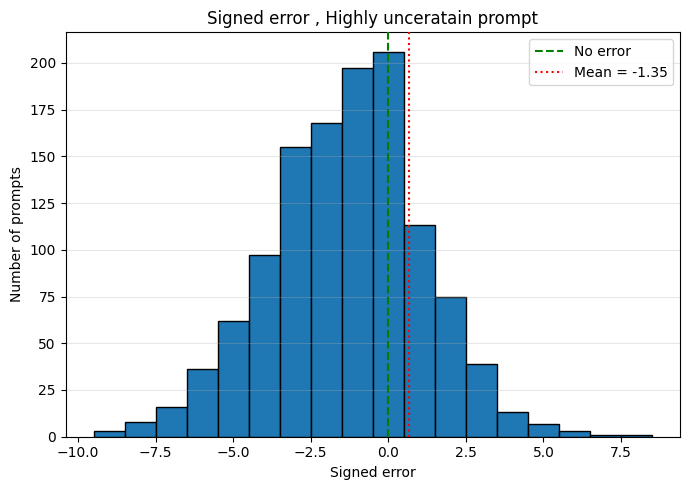

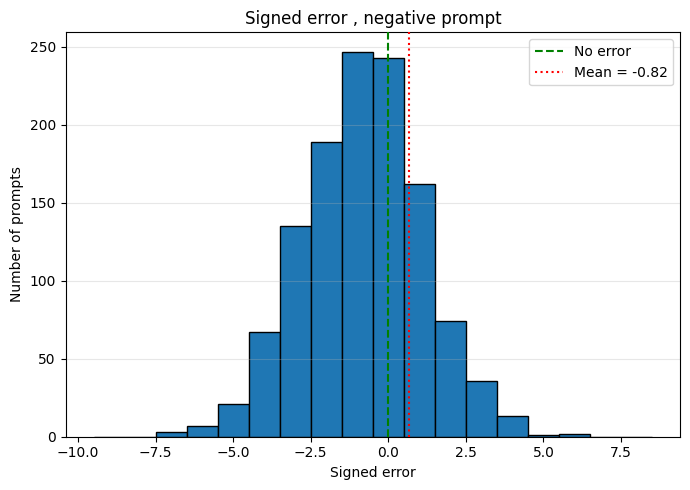

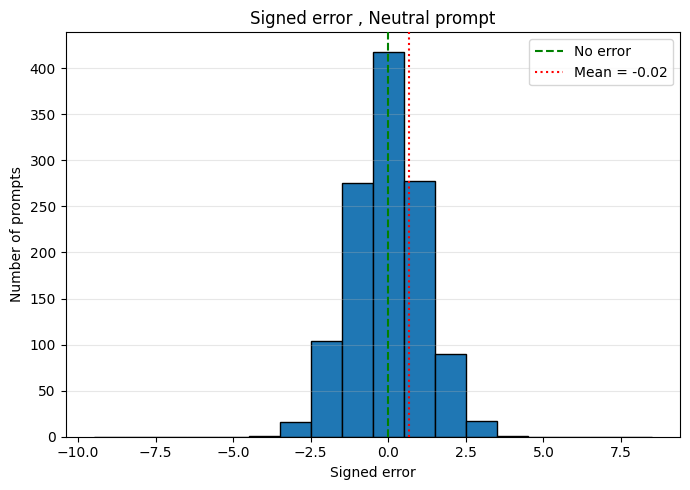

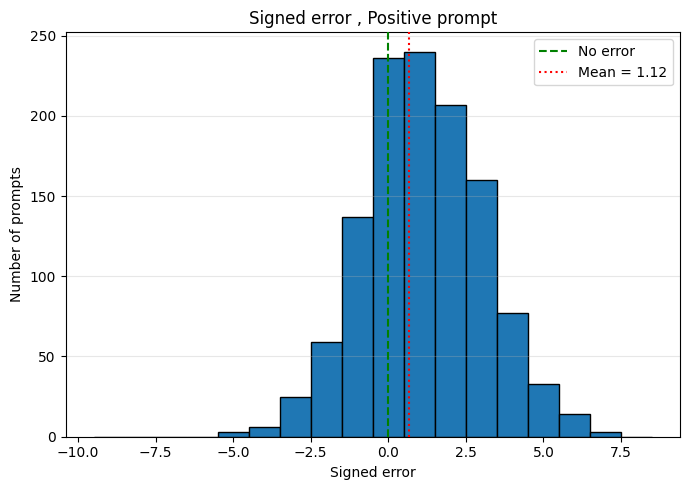

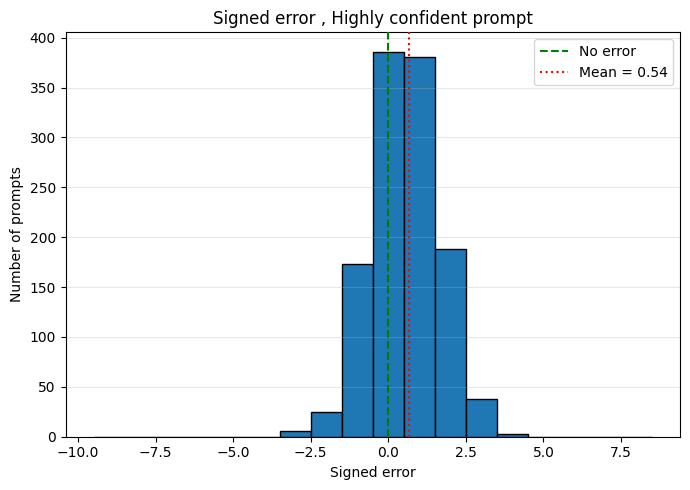

In [ ]:
#histogram over signed error
signed_min = int(df["signed_error"].min())
signed_max = int(df["signed_error"].max())

signed_hist = np.arange(
    signed_min - 0.5,
    signed_max + 1.5,
    1
)

for prompt, group in df.groupby("prompt"):

    plt.figure(figsize=(7, 5))

    plt.hist(
        group["signed_error"],
        bins=signed_hist,
        edgecolor="black",
        zorder=1
    )

    # Linje ved ingen fejl
    plt.axvline(
        0,
        linestyle="--",
        label="No error",
        color="green",
        zorder=3
    )

    mean_signederror = group["signed_error"].mean()

    plt.axvline(
        mean_error,
        linestyle=":",
        label=f"Mean = {mean_signederror:.2f}",
        zorder=4,
        color="red"
    )

    plt.title(
        f"Signed error , {prompt_names[prompt]} prompt"
    )

    plt.xlabel(
        "Signed error"
    )

    plt.ylabel("Number of prompts")
    plt.legend()
    plt.grid(axis="y", alpha=0.3,zorder=0)
    plt.tight_layout()
    plt.show()

C:\Users\sebhj\AppData\Local\Temp\ipykernel_11940\162779268.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


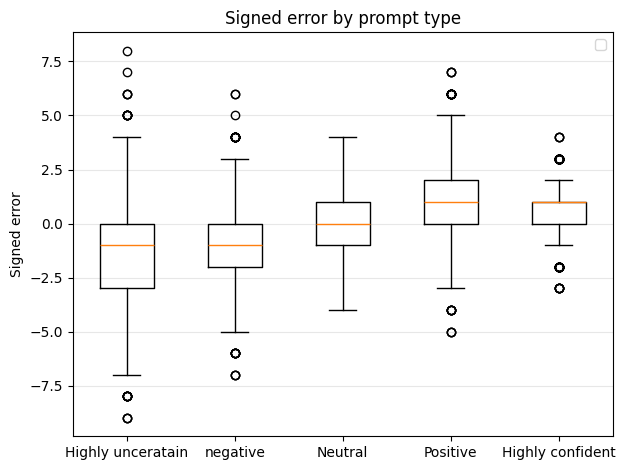

In [ ]:
#boxplot over signed error
signed_data = [
    df[df["prompt"] == 0]["signed_error"],
    df[df["prompt"] == 1]["signed_error"],
    df[df["prompt"] == 2]["signed_error"],
    df[df["prompt"] == 3]["signed_error"],
    df[df["prompt"] == 4]["signed_error"]
]


plt.boxplot(signed_data, tick_labels=[prompt_names[p] for p in range(5)]
)
plt.title("Signed error by prompt type")
plt.ylabel("Signed error")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\sebhj\AppData\Local\Temp\ipykernel_11940\1542584737.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


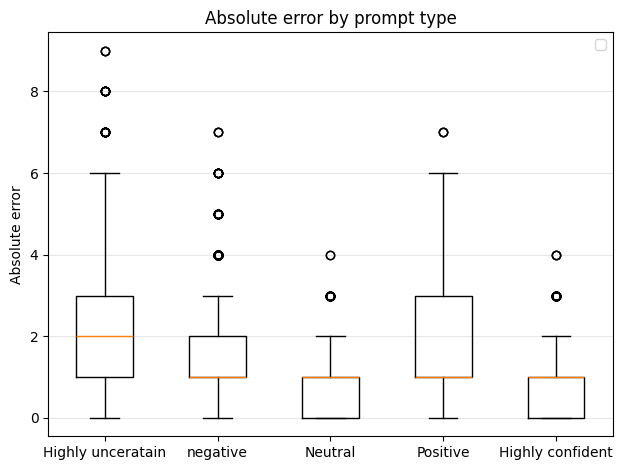

In [ ]:
#boxplot over absolut error
Absolute_data = [
    df[df["prompt"] == 0]["absolute_error"],
    df[df["prompt"] == 1]["absolute_error"],
    df[df["prompt"] == 2]["absolute_error"],
    df[df["prompt"] == 3]["absolute_error"],
    df[df["prompt"] == 4]["absolute_error"]
]
plt.boxplot(
    Absolute_data,
    tick_labels=[prompt_names[p] for p in range(5)]
)
plt.title("Absolute error by prompt type")
plt.ylabel("Absolute error")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Prompt 0: Hihgly Uncertain
Pearson r = 0.952
P-værdi = 0.000



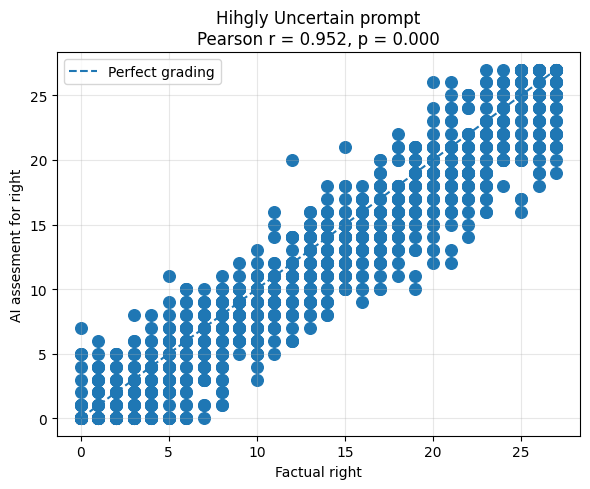

Prompt 1: Negative
Pearson r = 0.971
P-værdi = 0.000



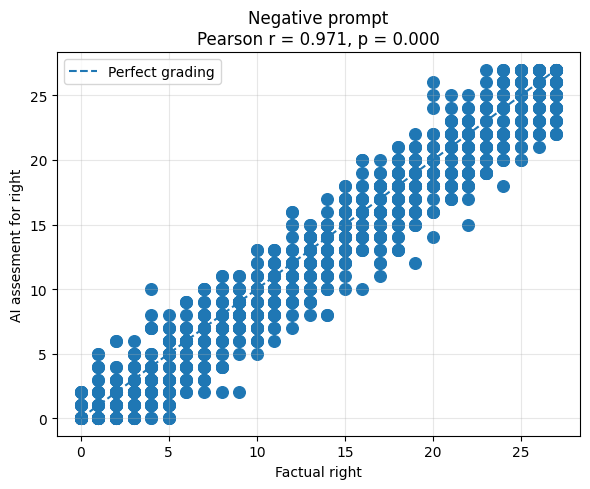

Prompt 2: Neutral
Pearson r = 0.989
P-værdi = 0.000



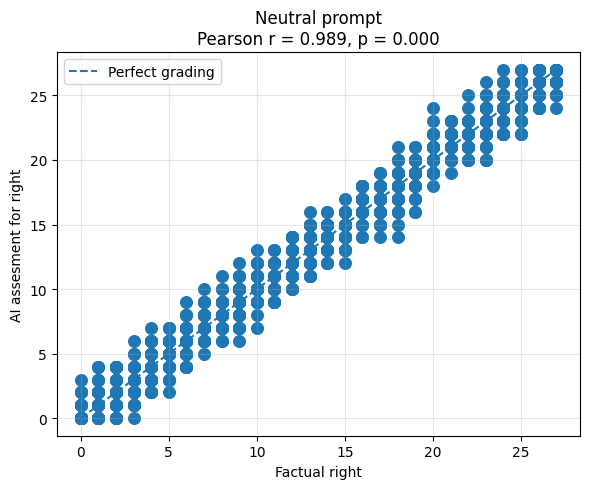

Prompt 3: Positive
Pearson r = 0.971
P-værdi = 0.000



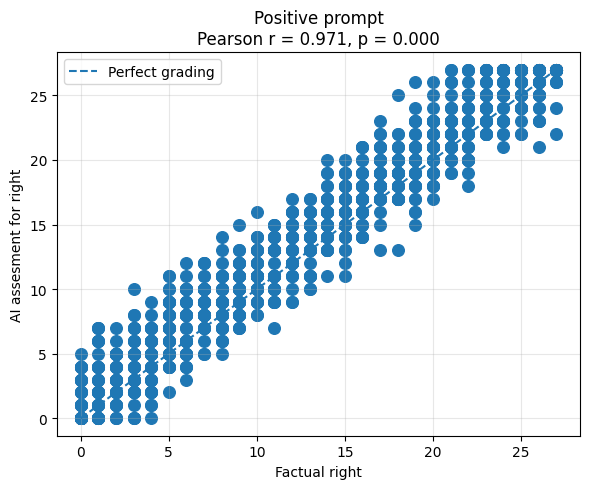

Prompt 4: Highly confident
Pearson r = 0.990
P-værdi = 0.000



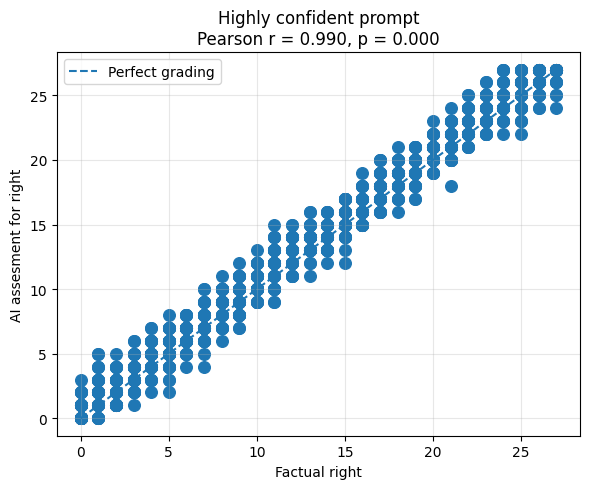

In [ ]:
#Pearson diagrammer over prompts
prompt_names = {
    1: "Negative",
    0: "Hihgly Uncertain",
    2: "Neutral",
    3: "Positive",
    4: "Highly confident"
}

for prompt, group in df.groupby("prompt"):

    factual = group["faktuelt rigtige"]
    ai_score = group["AI vurderet rigtig"]

    r, p_value = pearsonr(factual, ai_score)

    print(f"Prompt {prompt}: {prompt_names[prompt]}")
    print(f"Pearson r = {r:.3f}")
    print(f"P-værdi = {p_value:.3f}")
    print()

    plt.figure(figsize=(6, 5))

    plt.scatter(
        factual,
        ai_score,
        s=70
    )

    # Perfekt vurdering: AI-score = faktisk score
    minimum = min(factual.min(), ai_score.min())
    maximum = max(factual.max(), ai_score.max())

    plt.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--",
        label="Perfect grading"
    )

    plt.xlabel("Factual right")
    plt.ylabel("AI assesment for right")

    plt.title(
        f"{prompt_names[prompt]} prompt\n"
        f"Pearson r = {r:.3f}, p = {p_value:.3f}"
    )

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
#diskriptiv statestik
var_prompt = (
    df.groupby("prompt")
      .agg(
          signed_mean=("signed_error", "mean"),
          signed_variance=("signed_error", "var"),
          signed_std=("signed_error", "std"),
          absolute_mean=("absolute_error", "mean"),
          absolute_variance=("absolute_error", "var"),
          absolute_std=("absolute_error", "std")
      )
      .reset_index()
)

var_prompt["prompt_navn"] = (
    var_prompt["prompt"].map(prompt_names)
)

var_prompt_tabel = var_prompt[
    [
        "prompt",
        "prompt_navn",
        "signed_mean",
        "signed_variance",
        "signed_std",
        "absolute_mean",
        "absolute_variance",
        "absolute_std"
    ]
]

var_prompt_tabel = var_prompt_tabel.round(3)

print(var_prompt_tabel.to_string(index=False))

 prompt      prompt_navn  signed_mean  signed_variance  signed_std  absolute_mean  absolute_variance  absolute_std
      0 Hihgly Uncertain       -1.346            6.168       2.484          2.179              3.228         1.797
      1         Negative       -0.816            3.755       1.938          1.628              1.770         1.330
      2          Neutral       -0.018            1.382       1.176          0.873              0.619         0.787
      3         Positive        1.119            3.738       1.933          1.734              1.982         1.408
      4 Highly confident        0.535            1.256       1.121          0.937              0.665         0.815


C:\Users\sebhj\AppData\Local\Temp\ipykernel_11940\425539551.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


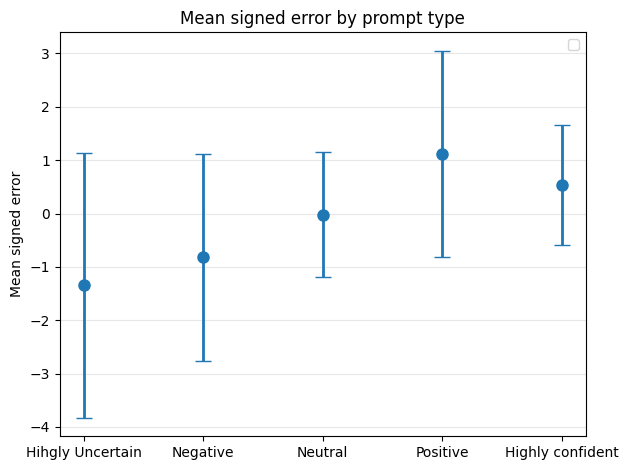

In [ ]:
#signed error, mean og standardafvigelse
plt.errorbar(
    var_prompt_tabel["prompt_navn"],
    var_prompt_tabel["signed_mean"],
    yerr=var_prompt_tabel["signed_std"],
    fmt="o",          # Punkt uden forbindelseslinje
    markersize=8,
    capsize=6,
    linewidth=2
)

plt.title("Mean signed error by prompt type")
plt.ylabel("Mean signed error")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\sebhj\AppData\Local\Temp\ipykernel_11940\950735199.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


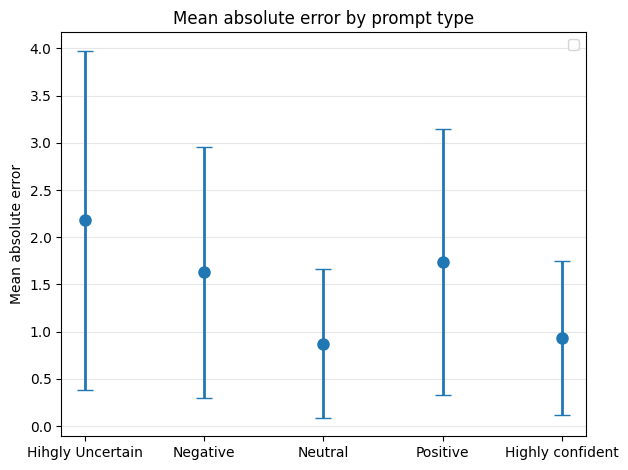

In [ ]:
#absolut error, mena og afvigelse
plt.errorbar(
    var_prompt_tabel["prompt_navn"],
    var_prompt_tabel["absolute_mean"],
    yerr=var_prompt_tabel["absolute_std"],
    fmt="o",
    markersize=8,
    capsize=6,
    linewidth=2
)
plt.title("Mean absolute error by prompt type")
plt.ylabel("Mean absolute error")

plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#antal data i de 10 perfomance grupper
df["faktuel_procent"] = (
    df["faktuelt rigtige"] / 27
) * 100

procent_grupper = [
    0, 10, 20, 30, 40, 50,
    60, 70, 80, 90, 100.000001
]

performance_labels = [
    "0-10%",
    "10-20%",
    "20-30%",
    "30-40%",
    "40-50%",
    "50-60%",
    "60-70%",
    "70-80%",
    "80-90%",
    "90-100%"
]

df["performance_group"] = pd.cut(
    df["faktuel_procent"],
    bins=procent_grupper,
    labels=performance_labels,
    right=False,
    include_lowest=True
)

print(
    df["performance_group"]
    .value_counts()
    .sort_index()
)

performance_group
0-10%      645
10-20%     645
20-30%     645
30-40%     430
40-50%     645
50-60%     645
60-70%     430
70-80%     645
80-90%     640
90-100%    630
Name: count, dtype: int64


In [ ]:
#fuld diskriptiv data over alle 50 mulige grupper
statistik_10pct = (
    df.groupby(
        ["performance_group", "prompt"],
        observed=False
    )
    .agg(
        n=("signed_error", "count"),

        signed_mean=("signed_error", "mean"),
        signed_median=("signed_error", "median"),
        signed_variance=("signed_error", "var"),
        signed_std=("signed_error", "std"),

        absolute_mean=("absolute_error", "mean"),
        absolute_median=("absolute_error", "median"),
        absolute_variance=("absolute_error", "var"),
        absolute_std=("absolute_error", "std")
    )
    .reset_index()
)

statistik_10pct["prompt_navn"] = (
    statistik_10pct["prompt"].map(prompt_names)
)

statistik_10pct = statistik_10pct[
    [
        "performance_group",
        "prompt",
        "prompt_navn",
        "n",
        "signed_mean",
        "signed_median",
        "signed_variance",
        "signed_std",
        "absolute_mean",
        "absolute_median",
        "absolute_variance",
        "absolute_std"
    ]
].round(3)

statistik_10pct

,performance_group,prompt,prompt_navn,n,signed_mean,signed_median,signed_variance,signed_std,absolute_mean,absolute_median,absolute_variance,absolute_std
0,0-10%,0,Hihgly Uncertain,129,0.155,0.0,3.320,1.822,1.287,1.0,1.675,1.294
1,0-10%,1,Negative,129,0.008,0.0,1.805,1.343,0.938,1.0,0.918,0.958
2,0-10%,2,Neutral,129,0.302,0.0,1.197,1.094,0.767,1.0,0.695,0.834
3,0-10%,3,Positive,129,1.481,1.0,3.564,1.888,1.822,1.0,2.429,1.558
4,0-10%,4,Highly confident,129,0.659,1.0,1.320,1.149,1.000,1.0,0.750,0.866
5,10-20%,0,Hihgly Uncertain,129,-1.256,-2.0,5.348,2.313,2.186,2.0,2.121,1.456
6,10-20%,1,Negative,129,-0.930,-1.0,4.019,2.005,1.798,2.0,1.631,1.277
7,10-20%,2,Neutral,129,-0.140,0.0,1.574,1.255,0.992,1.0,0.602,0.776
8,10-20%,3,Positive,129,1.287,1.0,4.831,2.198,2.062,2.0,2.215,1.488
9,10-20%,4,Highly confident,129,0.550,1.0,1.390,1.179,1.000,1.0,0.687,0.829


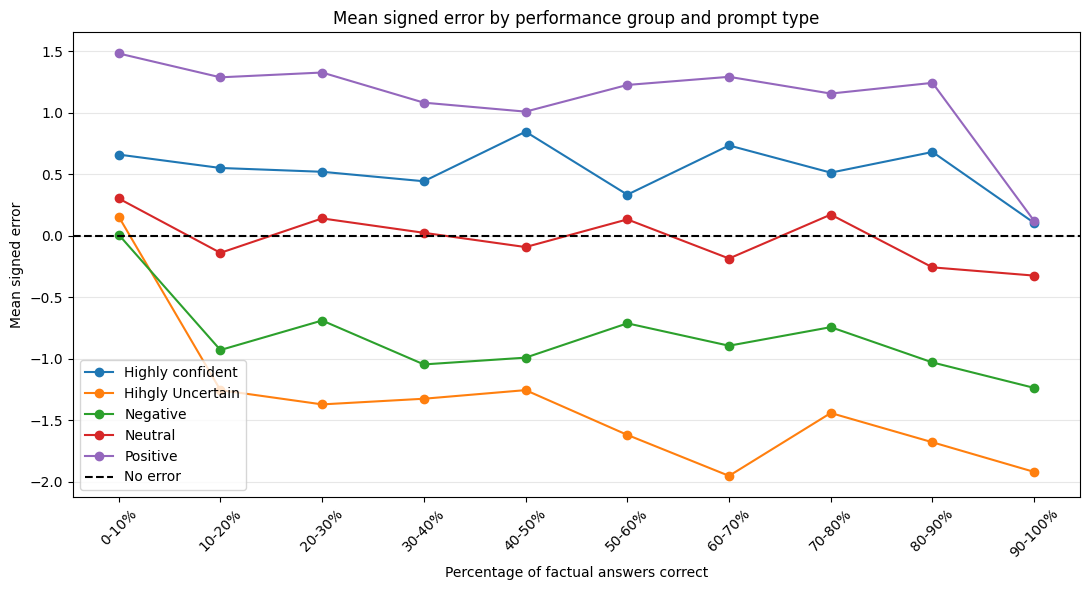

In [ ]:
#signed error i de 10 grupper og 5 prompts
signed_plot_data = statistik_10pct.pivot(
    index="performance_group",
    columns="prompt_navn",
    values="signed_mean"
)

plt.figure(figsize=(11, 6))

for prompt_name in signed_plot_data.columns:
    plt.plot(
        signed_plot_data.index.astype(str),
        signed_plot_data[prompt_name],
        marker="o",
        label=prompt_name
    )
plt.axhline(
    0,
    color="black",
    linestyle="--",
    label="No error"
)

plt.title("Mean signed error by performance group and prompt type")
plt.xlabel("Percentage of factual answers correct")
plt.ylabel("Mean signed error")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

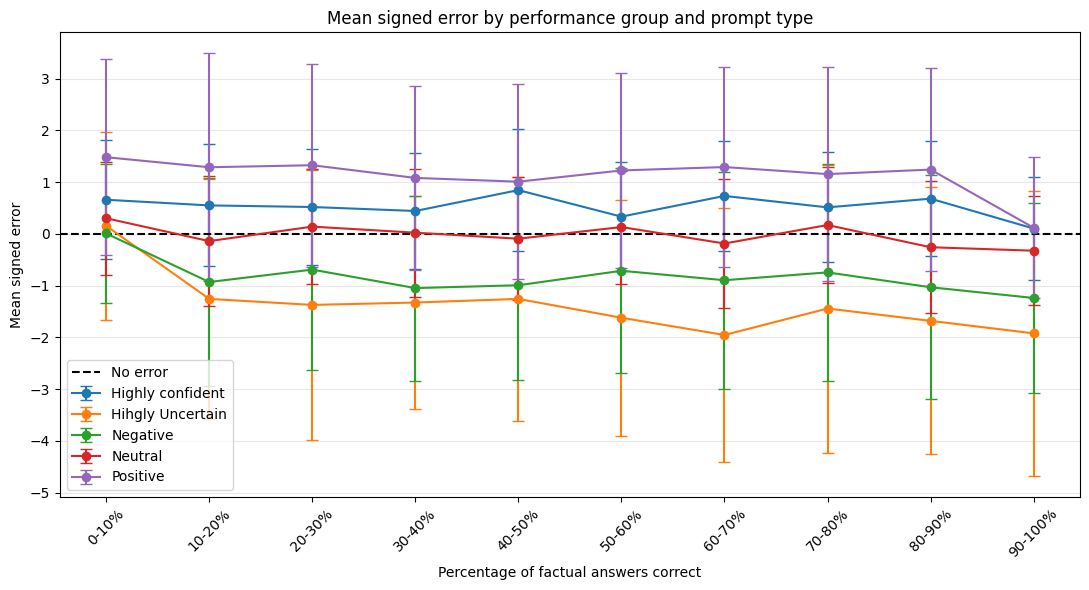

In [90]:
signed_plot_data = statistik_10pct.pivot(
    index="performance_group",
    columns="prompt_navn",
    values="signed_mean"
).reindex(performance_labels)

signed_std_data = statistik_10pct.pivot(
    index="performance_group",
    columns="prompt_navn",
    values="signed_std"
).reindex(performance_labels)

plt.figure(figsize=(11, 6))

for prompt_name in signed_plot_data.columns:

    plt.errorbar(
        signed_plot_data.index.astype(str),
        signed_plot_data[prompt_name],
        yerr=signed_std_data[prompt_name],
        marker="o",
        capsize=4,
        linewidth=1.5,
        label=prompt_name
    )

plt.axhline(
    0,
    color="black",
    linestyle="--",
    label="No error"
)

plt.title(
    "Mean signed error by performance group and prompt type"
)

plt.xlabel("Percentage of factual answers correct")
plt.ylabel("Mean signed error")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

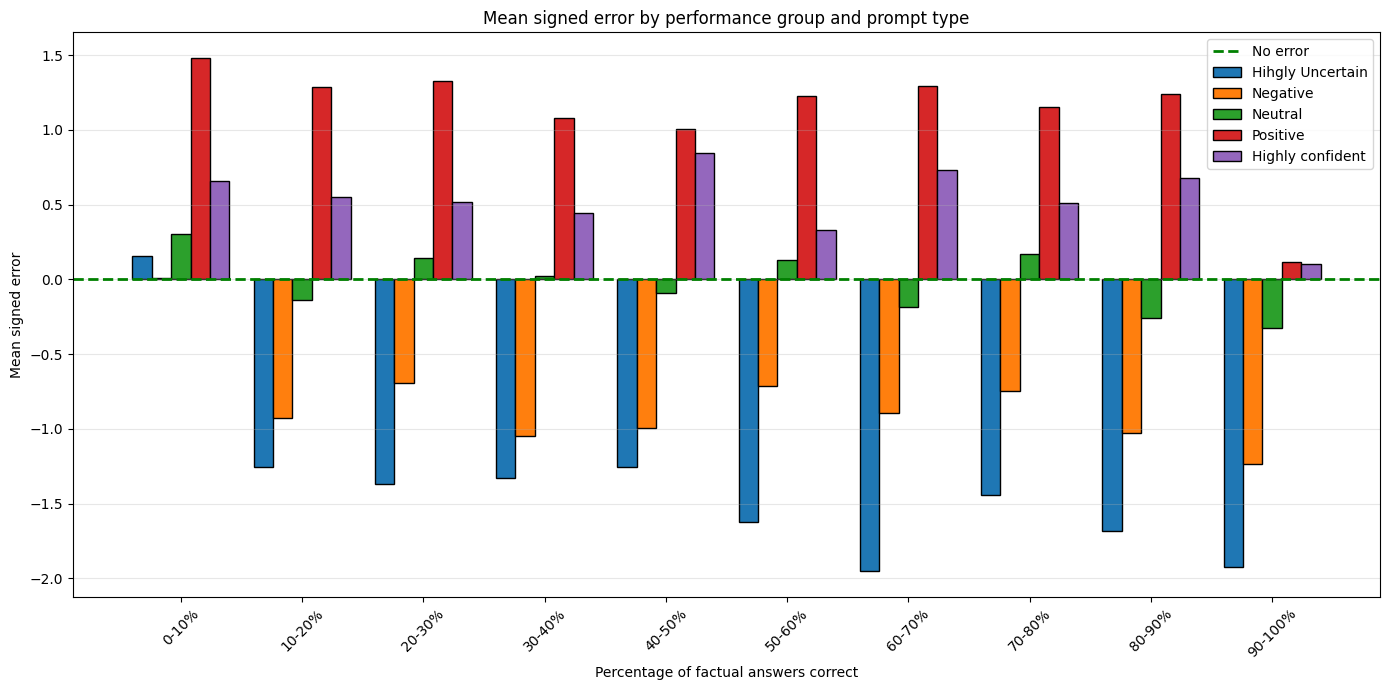

In [ ]:
#søjlediagram af de 10 grupper med de 5 prompts som søjler i hver gruppe, signed error
x = np.arange(len(performance_labels))
width = 0.16

plt.figure(figsize=(14, 7))

for i, prompt in enumerate(range(5)):

    prompt_data = (
        statistik_10pct[
            statistik_10pct["prompt"] == prompt
        ]
        .set_index("performance_group")
        .reindex(performance_labels)
    )

    signed_mean = prompt_data["signed_mean"].to_numpy(
        dtype=float
    )

    signed_variance = prompt_data["signed_variance"].to_numpy(
        dtype=float
    )

    # Flytter hver prompt lidt til siden inden for samme 10 %-gruppe
    position = x + (i - 2) * width

    plt.bar(
        position,
        signed_mean,
        width=width,
        label=prompt_names[prompt],
        edgecolor="black"
    )

plt.axhline(
    0,
    color="green",
    linestyle="--",
    linewidth=2,
    label="No error"
)

plt.xticks(
    x,
    performance_labels,
    rotation=45
)

plt.title(
    "Mean signed error by performance group and prompt type"
)

plt.xlabel("Percentage of factual answers correct")
plt.ylabel("Mean signed error")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

den samler de sheet + prompt som er ens til 1 mean til den sheet + prompt combo og derefter laves det nnye dataset hvor der så kun er 1 af hver tilfælde af sheet id+ prompt

In [100]:
# strukturere data til one-way repeated-measures
df_rm = (
    df.groupby(["sheet id", "prompt"], as_index=False)
      .agg(
          absolute_error=("absolute_error", "mean"),
          antal_gentagelser=("absolute_error", "count")
      )
)

prompt_count = (
    df_rm.groupby("sheet id")["prompt"]
         .nunique()
)

print(prompt_count.value_counts())

complete_sheets = prompt_count[
    prompt_count == 5
].index

df_rm = df_rm[
    df_rm["sheet id"].isin(complete_sheets)
].copy()

print(
    df_rm.groupby(["sheet id", "prompt"])
         .size()
         .value_counts()
)



prompt
5    1200
Name: count, dtype: int64
1    6000
Name: count, dtype: int64


<Figure size 900x500 with 0 Axes>

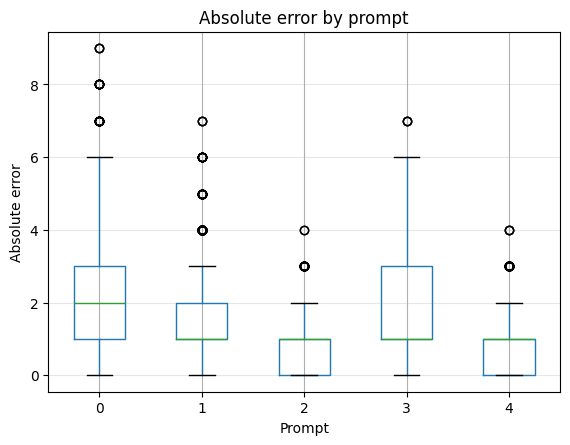

In [102]:
#boxplots med ny datasæt
plt.figure(figsize=(9, 5))

df_rm.boxplot(
    column="absolute_error",
    by="prompt"
)

plt.title("Absolute error by prompt")
plt.suptitle("")
plt.xlabel("Prompt")
plt.ylabel("Absolute error")
plt.grid(axis="y", alpha=0.3)
plt.show()

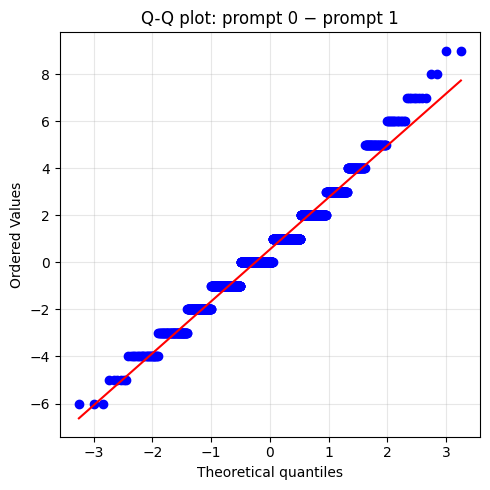

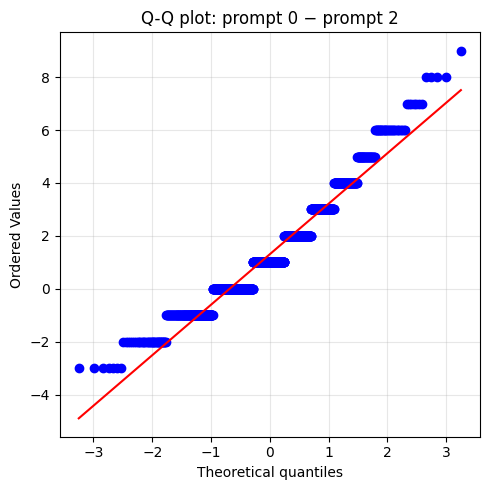

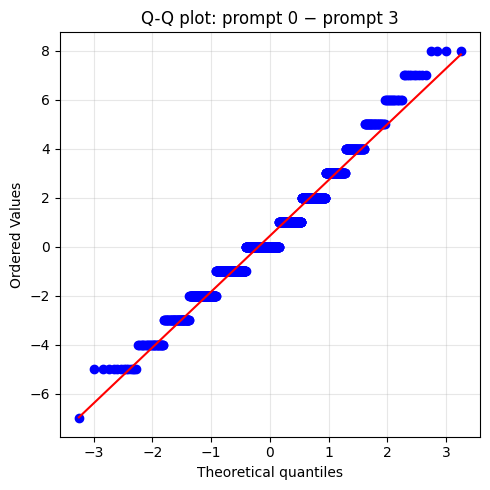

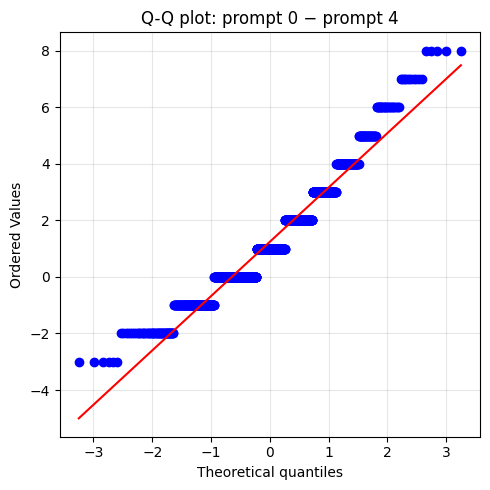

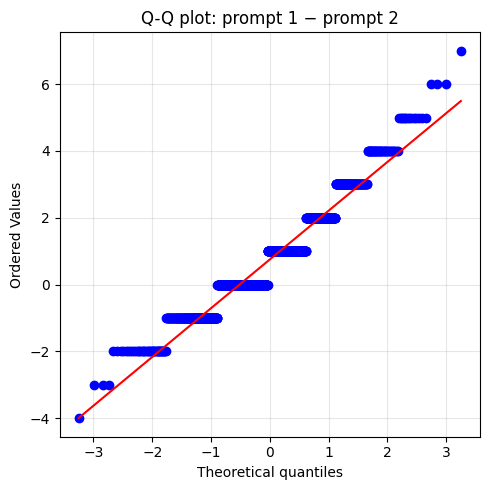

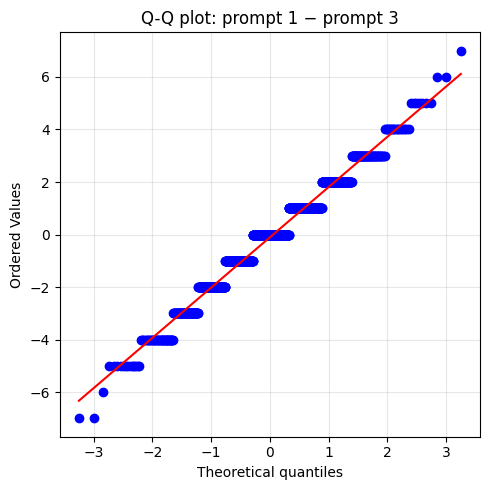

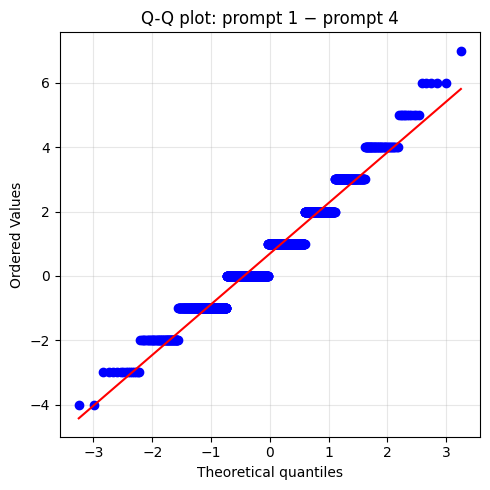

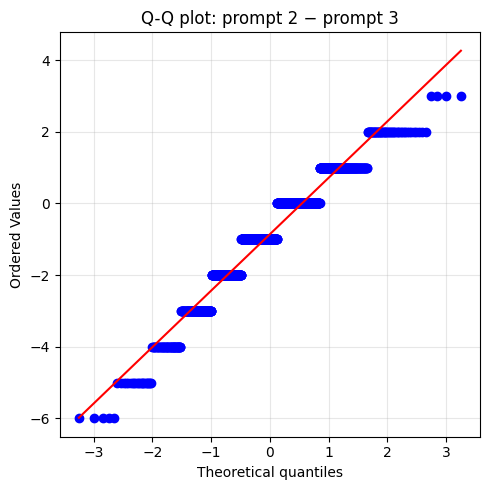

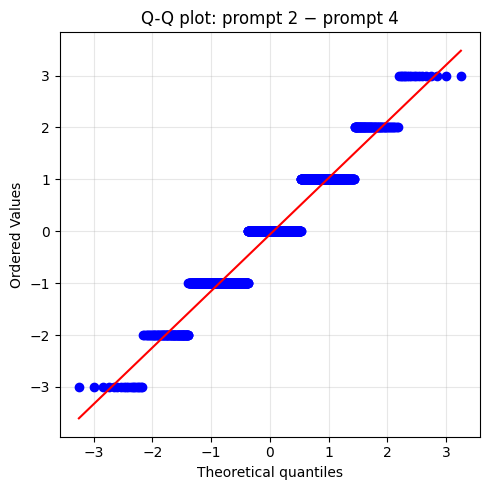

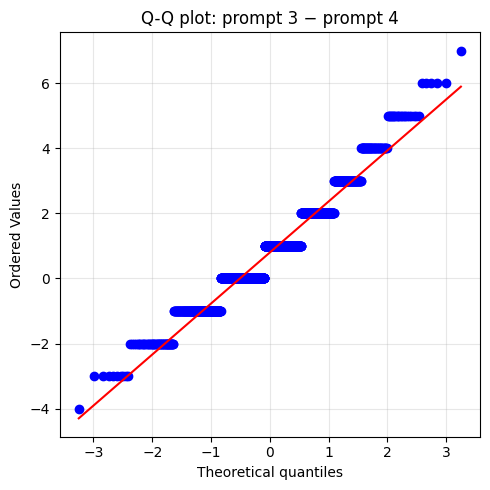

In [ ]:
wide = df_rm.pivot(
    index="sheet id",
    columns="prompt",
    values="absolute_error"
)


prompt_pairs = list(itertools.combinations(wide.columns, 2))

for prompt1, prompt2 in prompt_pairs:

    difference = (
        wide[prompt1] - wide[prompt2]
    ).dropna()

    plt.figure(figsize=(5, 5))

    stats.probplot(
        difference,
        dist="norm",
        plot=plt
    )

    plt.title(
        f"Q-Q plot: prompt {prompt1} − prompt {prompt2}"
    )

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
#x-akse: teoretiske standardnormal-kvantiler, altså hvor langt fra midten observationen burde ligge i en normalfordeling.
#y-akse: den faktiske sorterede forskel i absolute error mellem de to prompts.

In [ ]:
#repeated measures ANOVA, mellem prompt og absolut error. 
anova_data = df_rm[
    ["sheet_id", "prompt", "absolute_error"]
].copy()

# Konvertér til datatyper, som statsmodels kan læse
anova_data["sheet_id"] = anova_data["sheet_id"].astype("object")
anova_data["prompt"] = anova_data["prompt"].astype("object")
anova_data["absolute_error"] = pd.to_numeric(
    anova_data["absolute_error"],
    errors="coerce"
)

anova_data = anova_data.dropna()

print(anova_data.dtypes)

rm_anova = AnovaRM(
    data=anova_data,
    depvar="absolute_error",
    subject="sheet_id",
    within=["prompt"]
).fit()

print(rm_anova)

sheet_id           object
prompt             object
absolute_error    float64
dtype: object
                 Anova
       F Value  Num DF   Den DF  Pr > F
---------------------------------------
prompt 224.8613 4.0000 4796.0000 0.0000



F betyder, at variation grundet prompt type er stor ift variation ikke grundet prompt type. derfor viser det at mean af absoolute error variere grundet prompt type? og P værdien siger også dette da sandsynligheden for vi fik denne F værdi med mean værende ens er alt for lille

In [ ]:
#paired t-tests mellem hvert promptpar med Holm-korrektion. 
#corrected_p < 0.05: de to prompts har signifikant forskellige gennemsnitlige absolute errors.
#mean_difference > 0: prompt 1 har større absolute error end prompt 2.
#mean_difference < 0: prompt 1 har mindre absolute error end prompt 2.
#significant = True: forskellen er signifikant efter korrektionen.

wide = df_rm.pivot(
    index="sheet_id",
    columns="prompt",
    values="absolute_error"
)

results = []

for prompt1, prompt2 in itertools.combinations(wide.columns, 2):

    values1 = wide[prompt1]
    values2 = wide[prompt2]

    t_stat, p_value = ttest_rel(values1, values2)

    results.append({
        "prompt_1": prompt1,
        "prompt_2": prompt2,
        "mean_1": values1.mean(),
        "mean_2": values2.mean(),
        "mean_difference": (values1 - values2).mean(),
        "t_value": t_stat,
        "p_value": p_value
    })

pairwise_results = pd.DataFrame(results)

# Holm-korrektion
reject, corrected_p, _, _ = multipletests(
    pairwise_results["p_value"],
    alpha=0.05,
    method="holm"
)

pairwise_results["corrected_p"] = corrected_p
pairwise_results["significant"] = reject

print(pairwise_results.round(4).to_string(index=False))

 prompt_1  prompt_2  mean_1  mean_2  mean_difference  t_value  p_value  corrected_p  significant
        0         1  2.1792  1.6275           0.5517   8.5522   0.0000       0.0000         True
        0         2  2.1792  0.8733           1.3058  23.1228   0.0000       0.0000         True
        0         3  2.1792  1.7342           0.4450   6.6888   0.0000       0.0000         True
        0         4  2.1792  0.9367           1.2425  21.8597   0.0000       0.0000         True
        1         2  1.6275  0.8733           0.7542  17.4144   0.0000       0.0000         True
        1         3  1.6275  1.7342          -0.1067  -1.9081   0.0566       0.1033        False
        1         4  1.6275  0.9367           0.6908  14.8824   0.0000       0.0000         True
        2         3  0.8733  1.7342          -0.8608 -18.5045   0.0000       0.0000         True
        2         4  0.8733  0.9367          -0.0633  -1.9478   0.0517       0.1033        False
        3         4  1.7342  0

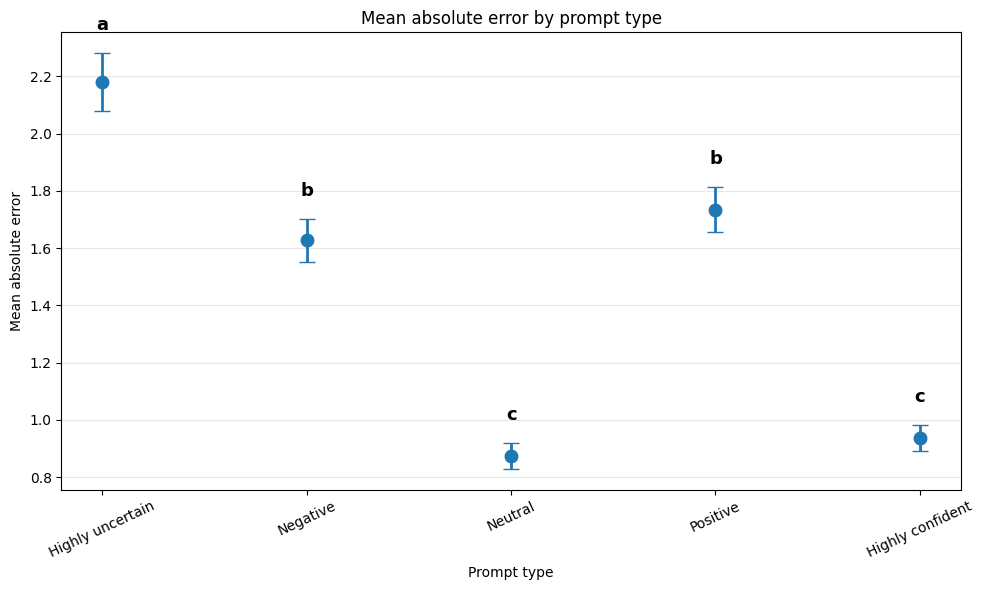

In [116]:
prompt_names = {
    0: "Highly uncertain",
    1: "Negative",
    2: "Neutral",
    3: "Positive",
    4: "Highly confident"
}

summary_plot = (
    df_rm.groupby("prompt")["absolute_error"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

summary_plot["sem"] = (
    summary_plot["std"] / np.sqrt(summary_plot["count"])
)

summary_plot["ci95"] = 1.96 * summary_plot["sem"]

# Samme bogstav = ikke signifikant forskellige
letters = {
    0: "a",
    1: "b",
    2: "c",
    3: "b",
    4: "c"
}

x = np.arange(len(summary_plot))

plt.figure(figsize=(10, 6))

plt.errorbar(
    x,
    summary_plot["mean"],
    yerr=summary_plot["ci95"],
    fmt="o",
    markersize=9,
    capsize=6,
    linewidth=2
)

for i, row in summary_plot.iterrows():
    plt.text(
        i,
        row["mean"] + row["ci95"] + 0.08,
        letters[row["prompt"]],
        ha="center",
        fontsize=13,
        fontweight="bold"
    )

plt.xticks(
    x,
    [prompt_names[p] for p in summary_plot["prompt"]],
    rotation=25
)

plt.ylabel("Mean absolute error")
plt.xlabel("Prompt type")
plt.title("Mean absolute error by prompt type")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

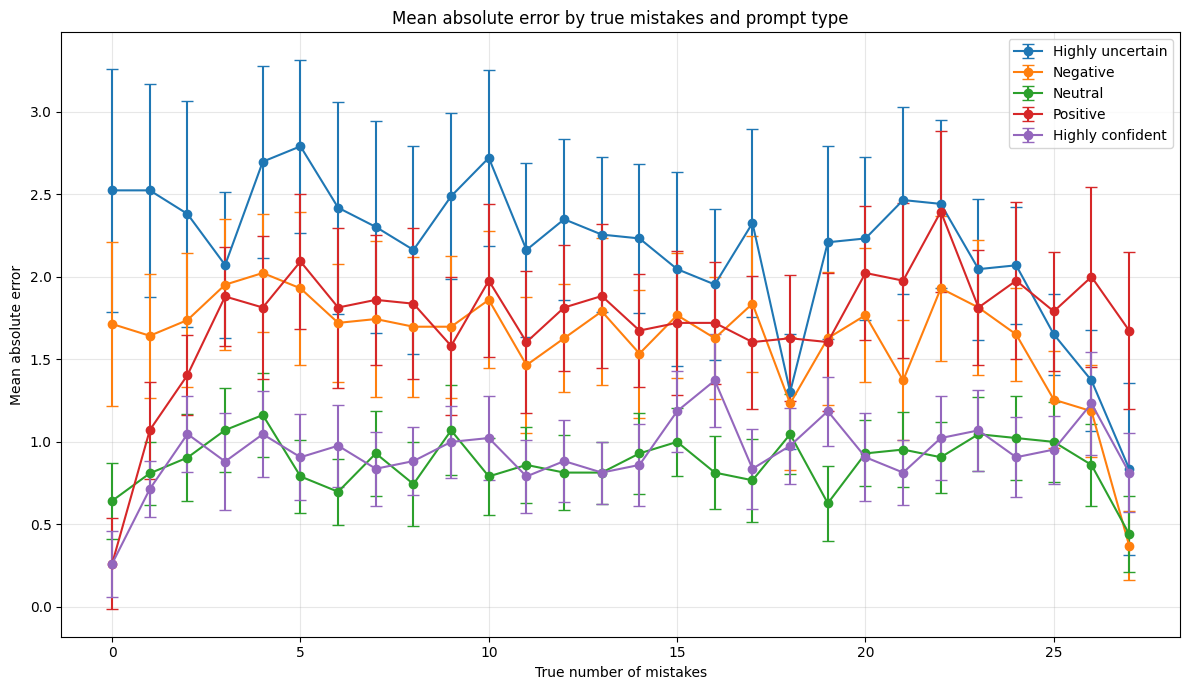

In [120]:
df["true_mistakes"] = 27 - df["faktuelt rigtige"]

df_rm = (
    df.groupby(["sheet id", "prompt"], as_index=False)
      .agg(
          absolute_error=("absolute_error", "mean"),
          true_mistakes=("true_mistakes", "first"),
          antal_gentagelser=("absolute_error", "count")
      )
)

df_rm = df_rm.rename(columns={"sheet id": "sheet_id"})


absolute_by_mistakes = (
    df_rm.groupby(["true_mistakes", "prompt"])["absolute_error"]
         .agg(["mean", "std", "count"])
         .reset_index()
)

absolute_by_mistakes["sem"] = (
    absolute_by_mistakes["std"]
    / np.sqrt(absolute_by_mistakes["count"])
)

absolute_by_mistakes["ci95"] = (
    1.96 * absolute_by_mistakes["sem"]
)

plt.figure(figsize=(12, 7))

for prompt in sorted(absolute_by_mistakes["prompt"].unique()):

    prompt_data = absolute_by_mistakes[
        absolute_by_mistakes["prompt"] == prompt
    ].sort_values("true_mistakes")

    plt.errorbar(
        prompt_data["true_mistakes"],
        prompt_data["mean"],
        yerr=prompt_data["ci95"],
        marker="o",
        capsize=4,
        label=prompt_names[prompt]
    )

plt.title(
    "Mean absolute error by true mistakes and prompt type"
)

plt.xlabel("True number of mistakes")
plt.ylabel("Mean absolute error")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

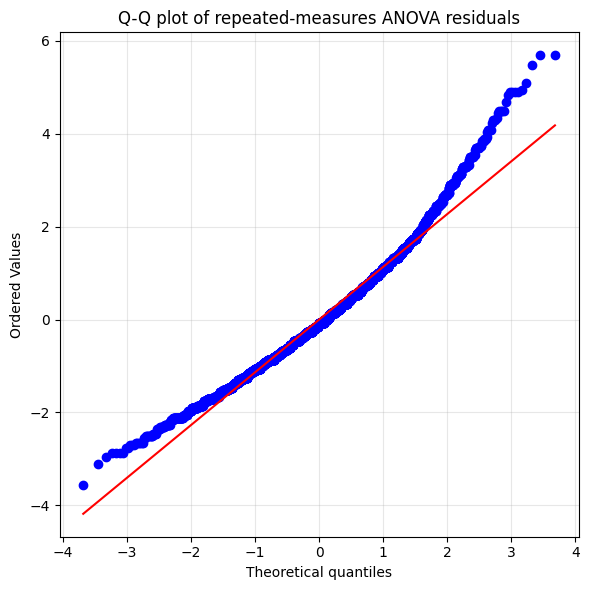

In [121]:
grand_mean = anova_data["absolute_error"].mean()

sheet_mean = (
    anova_data.groupby("sheet_id")["absolute_error"]
    .transform("mean")
)

prompt_mean = (
    anova_data.groupby("prompt")["absolute_error"]
    .transform("mean")
)

anova_data["fitted_value"] = (
    sheet_mean + prompt_mean - grand_mean
)

anova_data["residual"] = (
    anova_data["absolute_error"]
    - anova_data["fitted_value"]
)

plt.figure(figsize=(6, 6))

stats.probplot(
    anova_data["residual"],
    dist="norm",
    plot=plt
)

plt.title("Q-Q plot of repeated-measures ANOVA residuals")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

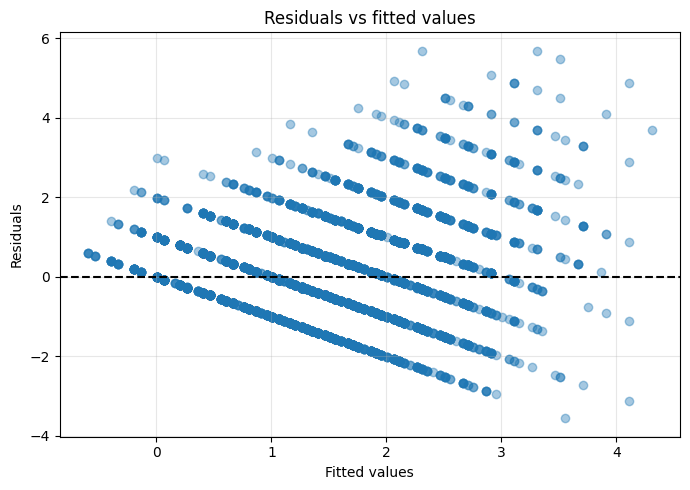

In [123]:
plt.figure(figsize=(7, 5))

plt.scatter(
    anova_data["fitted_value"],
    anova_data["residual"],
    alpha=0.4
)

plt.axhline(
    0,
    color="black",
    linestyle="--"
)

plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs fitted values")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
#test chat foreslog hvis data ikke var normalfordelt. 
from scipy.stats import friedmanchisquare

wide = anova_data.pivot(
    index="sheet_id",
    columns="prompt",
    values="absolute_error"
)

friedman_stat, friedman_p = friedmanchisquare(
    *[wide[prompt] for prompt in wide.columns]
)

print("Friedman statistic:", friedman_stat)
print("p-value:", friedman_p)wide = anova_data.pivot(
    index="sheet_id",
    columns="prompt",
    values="absolute_error"
)

friedman_stat, friedman_p = friedmanchisquare(
    *[wide[prompt] for prompt in wide.columns]
)

print("Friedman statistic:", friedman_stat)
print("p-value:", friedman_p)

Friedman statistic: 604.0466793549008
p-value: 2.062558391719697e-129
